# Bitcoin Price Prediction: Deep Learning vs. Ridge Regression

## Objective

This notebook compares four PyTorch sequence models with a Ridge baseline for next-day Bitcoin return prediction.

We focus on three practical metrics: directional accuracy, annualized Sharpe ratio from a sign-based strategy, and RMSE for error context.

All models use the same feature pipeline, so differences come from model behavior rather than preprocessing.

## Stage 1: Initialization and Sequence Data Construction

This section prepares data for both tabular and sequence models.

Traditional sklearn models use 2D inputs $(N, F)$, while temporal neural models use 3D inputs $(N, T, F)$ with lookback window $T$.

To avoid leakage, scaling is fit on training data only. Sequences are built after splitting, and the test dataframe is aligned with sequence targets.

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DATA_PATH = "../data/raw/bitcoin_price_training_data.csv"
WINDOW_SIZE = 7

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"], format="%b %d, %Y", errors="coerce")
if df["Date"].isna().all():
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values("Date", ascending=True).reset_index(drop=True)


def clean_currency_series(s: pd.Series) -> pd.Series:
    cleaned = (
        s.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("-", "0", regex=False)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors="coerce")


for col in ["Volume", "Market Cap"]:
    if col in df.columns:
        df[col] = clean_currency_series(df[col])

df["Return_1d"] = df["Close"].pct_change()
df["Return_3d"] = df["Close"].pct_change(3)
sma_7 = df["Close"].rolling(window=7, min_periods=7).mean()
df["SMA_7_diff"] = (df["Close"] - sma_7) / sma_7
df["Volatility_7"] = df["Return_1d"].rolling(window=7, min_periods=7).std()

df["Next_Return"] = df["Return_1d"].shift(-1)
df["Next_Close"] = df["Close"].shift(-1)

feature_cols = ["Return_1d", "Return_3d", "SMA_7_diff", "Volatility_7"]
df = df.dropna(subset=feature_cols + ["Next_Return", "Next_Close"]).reset_index(drop=True)

X_all = df[feature_cols]
y_all = df["Next_Return"]

split_idx = int(len(df) * 0.8)
X_train_2d = X_all.iloc[:split_idx]
X_test_2d = X_all.iloc[split_idx:]
y_train_1d = y_all.iloc[:split_idx]
y_test_1d = y_all.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)


def create_sequences(data, target, window_size=7):
    data = np.asarray(data, dtype=np.float32)
    target = np.asarray(target, dtype=np.float32)
    X_list, y_list = [], []
    for i in range(window_size, len(data)):
        X_list.append(data[i - window_size : i])
        y_list.append(target[i])
    return np.stack(X_list, axis=0), np.array(y_list, dtype=np.float32)


X_train, y_train = create_sequences(X_train_scaled, y_train_1d.values, WINDOW_SIZE)
X_test, y_test = create_sequences(X_test_scaled, y_test_1d.values, WINDOW_SIZE)

offset = split_idx + WINDOW_SIZE
test_df = df.iloc[offset : offset + len(y_test)].copy().reset_index(drop=True)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("test_df rows (aligned with y_test):", len(test_df))

X_train: (1231, 7, 4) X_test: (303, 7, 4)
test_df rows (aligned with y_test): 303


## Stage 2: Unified Evaluation Framework

Every model is evaluated with one shared protocol:

- RMSE in price space
- Directional accuracy
- Annualized Sharpe ratio from a sign-based strategy

This keeps comparisons fair and tied to practical trading-style outcomes.

In [10]:
def evaluate_model(model_name, predictions, test_df):
    close = test_df["Close"].to_numpy(dtype=float)
    actual_next_close = test_df["Next_Close"].to_numpy(dtype=float)
    actual_next_return = test_df["Next_Return"].to_numpy(dtype=float)

    pred = np.asarray(predictions, dtype=float).ravel()
    predicted_direction = np.sign(pred)
    pred_price = close * (1.0 + pred)
    rmse = float(np.sqrt(mean_squared_error(actual_next_close, pred_price)))

    actual_dir = np.sign(actual_next_return)
    actual_dir = np.where(actual_dir == 0, 1, actual_dir)
    directional_accuracy = float(np.mean(predicted_direction == actual_dir) * 100.0)

    strategy_return = predicted_direction * actual_next_return
    std = np.std(strategy_return, ddof=1)
    annualized_sharpe = (
        float(np.sqrt(365.0) * np.mean(strategy_return) / std) if std > 0 else float("nan")
    )

    return {
        "Model": model_name,
        "RMSE": rmse,
        "Directional_Accuracy_%": directional_accuracy,
        "Annualized_Sharpe": annualized_sharpe,
    }

## Stage 3: Deep Learning Architecture Definitions

Four compact PyTorch baselines are defined:

- MLP on flattened windows
- 1D-CNN for local temporal patterns
- LSTM for recurrent memory
- GRU as a lighter recurrent alternative

Dropout is included to reduce overfitting on noisy return data.

In [11]:
n_features = X_train.shape[2]


class MLPNet(nn.Module):
    def __init__(self, window: int, n_feat: int):
        super().__init__()
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(window * n_feat, 64)
        self.drop = nn.Dropout(0.2)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.flat(x)
        x = torch.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x).squeeze(-1)


class CNN1DNet(nn.Module):
    def __init__(self, n_feat: int, window: int, kernel_size: int = 3):
        super().__init__()
        self.conv = nn.Conv1d(n_feat, 32, kernel_size)
        l_out = window - kernel_size + 1
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(32 * l_out, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = torch.relu(self.conv(x))
        x = self.flat(x)
        x = torch.relu(self.fc1(x))
        return self.fc2(x).squeeze(-1)


class LSTMNet(nn.Module):
    def __init__(self, n_feat: int, hidden: int = 32):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, batch_first=True)
        self.drop = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.drop(out)
        return self.fc(out).squeeze(-1)


class GRUNet(nn.Module):
    def __init__(self, n_feat: int, hidden: int = 32):
        super().__init__()
        self.gru = nn.GRU(n_feat, hidden, batch_first=True)
        self.drop = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.drop(out)
        return self.fc(out).squeeze(-1)


def model_factory(name: str) -> nn.Module:
    if name == "MLP":
        return MLPNet(WINDOW_SIZE, n_features)
    if name == "1D-CNN":
        return CNN1DNet(n_features, WINDOW_SIZE)
    if name == "LSTM":
        return LSTMNet(n_features)
    if name == "GRU":
        return GRUNet(n_features)
    raise ValueError(name)


MODEL_NAMES = ["MLP", "1D-CNN", "LSTM", "GRU"]

## Stage 4: Training Procedure with Early Stopping

Validation is taken from the tail of the training period to preserve time order.

Early stopping monitors validation MSE and restores the best weights.

This helps limit overfitting while keeping the setup time-series aware.

In [12]:
def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def train_with_early_stopping(
    model: nn.Module,
    X_train_np: np.ndarray,
    y_train_np: np.ndarray,
    device: torch.device,
    epochs: int = 100,
    batch_size: int = 32,
    val_frac: float = 0.1,
    patience: int = 10,
):
    n = len(X_train_np)
    n_val = max(1, int(n * val_frac))
    n_tr = n - n_val
    X_tr, y_tr = X_train_np[:n_tr], y_train_np[:n_tr]
    X_val, y_val = X_train_np[n_tr:], y_train_np[n_tr:]

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32, device=device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32, device=device)

    loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=batch_size,
        shuffle=False,
    )

    model = model.to(device)
    opt = torch.optim.Adam(model.parameters())
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    bad = 0

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            vpred = model(X_val_t)
            val_loss = loss_fn(vpred, y_val_t).item()

        if val_loss < best_val - 1e-12:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(device)
    return model


def predict_numpy(model: nn.Module, X_np: np.ndarray, device: torch.device) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(X_np, dtype=torch.float32, device=device)
        return model(xt).cpu().numpy()


device = pick_device()
print("Device:", device)

results_rows = []
for name in MODEL_NAMES:
    torch.manual_seed(RANDOM_SEED)
    m = model_factory(name)
    m = train_with_early_stopping(m, X_train, y_train, device)
    pred = predict_numpy(m, X_test, device)
    results_rows.append(evaluate_model(name, pred, test_df))

results_rows

Device: mps


[{'Model': 'MLP',
  'RMSE': 70.08369003813577,
  'Directional_Accuracy_%': 60.396039603960396,
  'Annualized_Sharpe': 1.9786125827078638},
 {'Model': '1D-CNN',
  'RMSE': 72.11954536458514,
  'Directional_Accuracy_%': 59.07590759075908,
  'Annualized_Sharpe': 1.7929450484390803},
 {'Model': 'LSTM',
  'RMSE': 72.4790751160721,
  'Directional_Accuracy_%': 60.396039603960396,
  'Annualized_Sharpe': 1.942043370736948},
 {'Model': 'GRU',
  'RMSE': 72.83608938369184,
  'Directional_Accuracy_%': 57.755775577557756,
  'Annualized_Sharpe': 1.6783886740741376}]

## Stage 5: Ridge Baseline

Ridge regression with alpha = 100.0 is used as a strong regularized baseline.

It provides a simple and interpretable reference against the deep models.

In [13]:
ridge = Ridge(alpha=100.0, random_state=RANDOM_SEED)
ridge.fit(X_train_2d, y_train_1d.values)

# Match RidgeRegression.ipynb protocol: no scaler and no window offset.
ridge_pred = ridge.predict(X_test_2d)
test_df_ridge = df.iloc[split_idx:].copy().reset_index(drop=True)

ridge_metrics = evaluate_model(
    "Ridge (α=100, RidgeRegression.ipynb)",
    ridge_pred,
    test_df_ridge,
)

# Keep only one Ridge row if this cell is re-run.
results_rows = [r for r in results_rows if not str(r.get("Model", "")).startswith("Ridge")]
results_rows.append(ridge_metrics)

comparison_df = pd.DataFrame(results_rows).set_index("Model")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
comparison_df

,RMSE,Directional_Accuracy_%,Annualized_Sharpe
Model,,,
MLP,70.0837,60.3960,1.9786
1D-CNN,72.1195,59.0759,1.7929
LSTM,72.4791,60.3960,1.9420
GRU,72.8361,57.7558,1.6784
"Ridge (α=100, RidgeRegression.ipynb)",68.9133,63.5484,2.9358


### Annualized Sharpe Comparison Across Models

This chart compares risk-adjusted strategy performance for all models on the same test window.

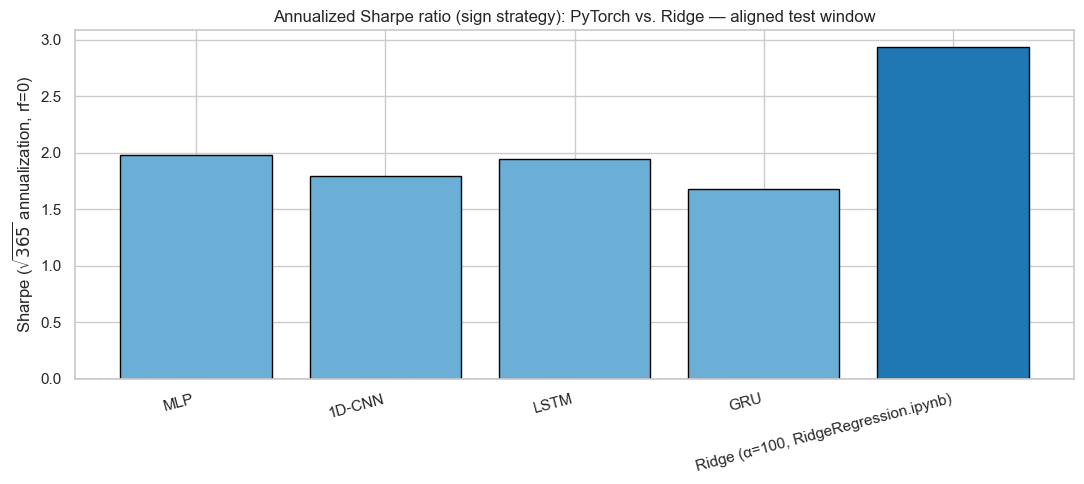

In [14]:
plot_df = comparison_df.reset_index()
fig, ax = plt.subplots(figsize=(11, 5))
order = ["MLP", "1D-CNN", "LSTM", "GRU", "Ridge (α=100, RidgeRegression.ipynb)"]
plot_df["Model"] = pd.Categorical(plot_df["Model"], categories=order, ordered=True)
plot_df = plot_df.sort_values("Model")
colors = ["#1f77b4" if str(m).startswith("Ridge") else "#6baed6" for m in plot_df["Model"]]
ax.bar(plot_df["Model"].astype(str), plot_df["Annualized_Sharpe"], color=colors, edgecolor="black")
ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Annualized Sharpe ratio (sign strategy): PyTorch vs. Ridge — aligned test window")
ax.set_xlabel("")
ax.set_ylabel("Sharpe ($\\sqrt{365}$ annualization, rf=0)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Conclusion

Deep models can capture nonlinear patterns, but gains depend on data size and signal stability.

In this setup, Ridge remains competitive and robust out of sample.
